In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# For comparison
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv(r"C:\Users\User\Downloads\ML\EXP-7\archive\Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

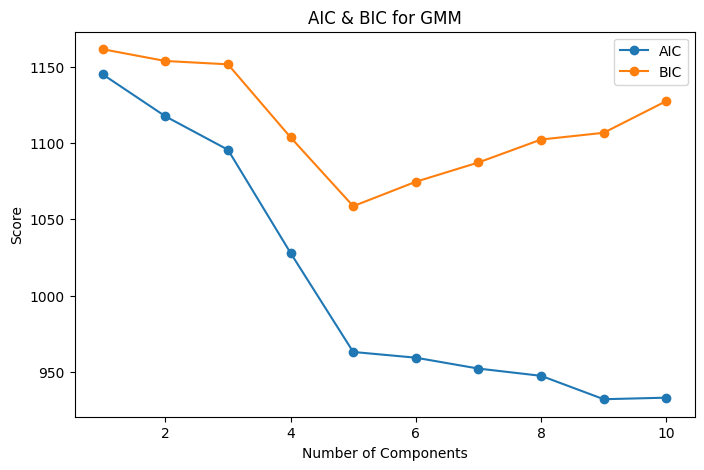

In [7]:
aic = []
bic = []

K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

# Plot AIC & BIC
plt.figure(figsize=(8,5))
plt.plot(K_range, aic, label='AIC', marker='o')
plt.plot(K_range, bic, label='BIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('AIC & BIC for GMM')
plt.legend()
plt.show()

In [8]:
# Choose optimal components (example: 5)
gmm = GaussianMixture(n_components=5, random_state=42)

# Fit model (EM algorithm)
gmm.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [9]:
# Soft clustering (probabilities)
probs = gmm.predict_proba(X_scaled)

# Show first few probability distributions
pd.DataFrame(probs).head()

,0,1,2,3,4
0,1.576897e-05,1.880092e-08,9.520312e-04,5.200131e-08,0.999032
1,1.627762e-05,1.895968e-04,9.997902e-01,4.210134e-23,0.000004
2,2.213394e-19,9.526157e-19,1.225495e-12,1.862233e-04,0.999814
3,1.054448e-04,1.800877e-04,9.996937e-01,3.793901e-21,0.000021
4,6.473014e-05,3.842732e-08,1.556695e-03,4.757227e-08,0.998378


In [10]:
# Hard clustering
labels = gmm.predict(X_scaled)

df['GMM_Cluster'] = labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),GMM_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [11]:
# Log Likelihood
log_likelihood = gmm.score(X_scaled)
print("Log-Likelihood:", log_likelihood)

# AIC & BIC
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

# Silhouette Score
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


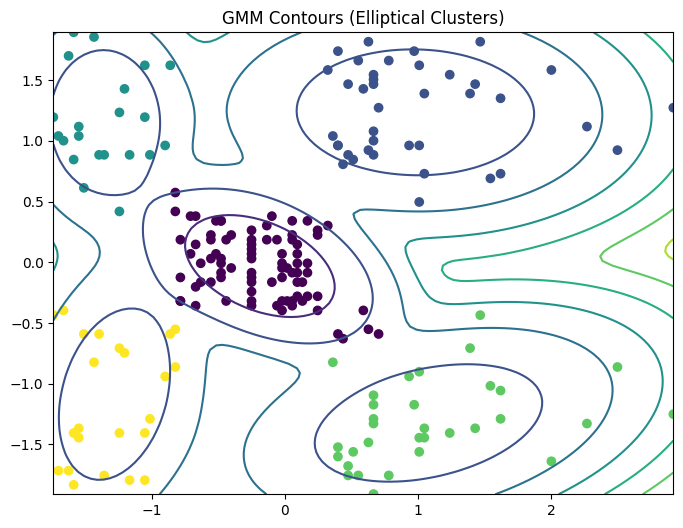

In [12]:
# Create grid for contour
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure(figsize=(8,6))
plt.contour(X_grid, Y_grid, Z)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.title('GMM Contours (Elliptical Clusters)')
plt.show()

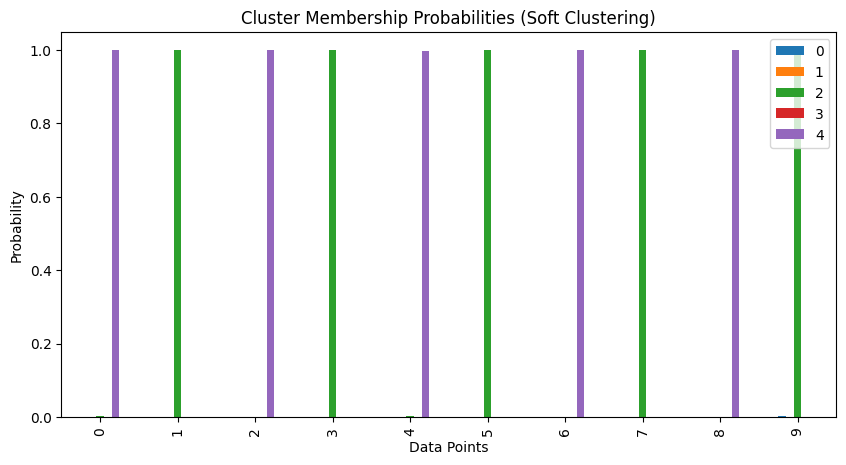

In [13]:
# Plot probability distribution for first 10 samples
pd.DataFrame(probs[:10]).plot(kind='bar', figsize=(10,5))
plt.title('Cluster Membership Probabilities (Soft Clustering)')
plt.xlabel('Data Points')
plt.ylabel('Probability')
plt.show()

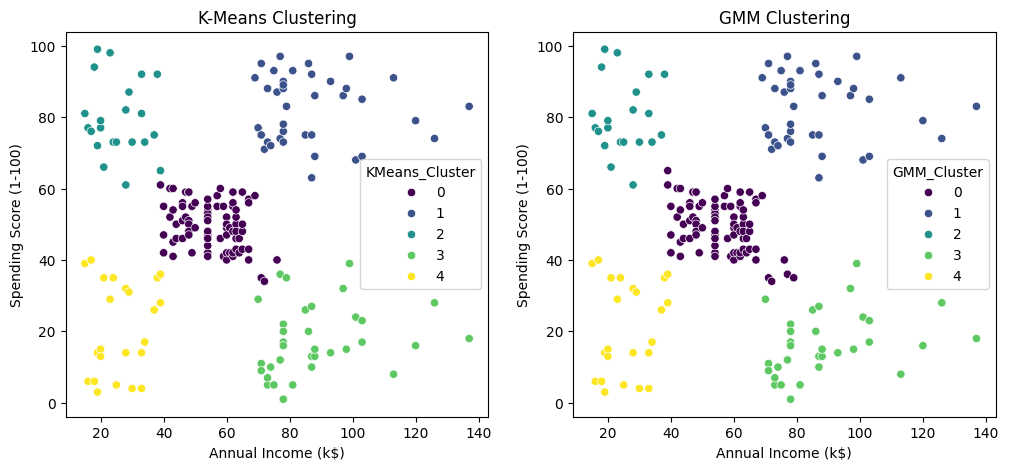

In [14]:
# K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)
plt.title('K-Means Clustering')

# GMM
plt.subplot(1,2,2)
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['GMM_Cluster'],
    palette='viridis'
)
plt.title('GMM Clustering')

plt.show()